# 🏷️ **Project Name**
Integrated Retail Analytics for Store Optimization


##### 📊 **Project Type**
EDA / Regression / Time Series Forecasting / Unsupervised Learning


# 📝 **Project Summary**


📌 **Selected Category:** Category 2 - Personalized Customer Segmentation in E-commerce / Retail

Retail businesses do not lose money only because sales are low. They also lose money when stores are planned in the same way even though they behave differently, when demand spikes are treated as normal, when promotions are not reviewed properly, and when inventory decisions are made without a clear view of upcoming demand. This project is built around that business problem.

The dataset represents weekly Walmart sales across **45 stores**, **81 departments**, and dates from **February 2010 to October 2012**. The sales table tells us what was sold, where it was sold, and during which week. The features table adds the weekly business environment around those sales, such as markdown activity, weather, fuel price, CPI, unemployment, and holiday timing. The stores table adds the identity of each store through store type and size. Together, these tables allow the project to move from raw sales records to a more complete retail decision view.

The selected category is retail segmentation, so store grouping is an important part of the project. However, the project description also asks for anomaly detection, market basket analysis, demand forecasting, external factors, and business strategy. For that reason, the notebook builds an integrated retail analytics workflow rather than a single-model exercise.

The work starts with data understanding, cleaning, and feature engineering. It then studies sales patterns through visual analysis and hypothesis testing. After that, it identifies unusual sales behavior, creates store segments, builds proxy department association rules, and compares forecasting models. The forecasting section includes both an overall weekly sales model for strategic demand planning and a store-department benchmark for more operational demand tracking.

🎯 **Project goal:** turn weekly retail data into practical insights that can support inventory planning, promotion review, store segmentation, anomaly monitoring, and demand forecasting in a business-friendly way.


# **GitHub Link -**


[GitHub Repository](https://github.com/I-AM-PRASHANT-VERMA/Almabetter---Integrated-Retail-Analytics-for-Store-Optimization-)


# 🎯 **Problem Statement**


The business problem is to understand how different stores, departments, promotions, holidays, and external conditions affect weekly retail sales. A store manager or retail planning team cannot make strong decisions by looking only at total sales. They need to know which stores behave similarly, which departments drive revenue, which weeks are unusual, and which demand patterns can be forecasted with reasonable confidence.

📍 **What this project is trying to achieve**

- 🛒 Understand the structure and quality of the sales, features, and stores data.
- 🧹 Create a clean merged dataset that connects sales with store information and weekly business conditions.
- 📈 Study sales patterns across time, holidays, store types, departments, markdowns, and economic variables.
- 🚨 Detect unusual sales weeks so they can be reviewed instead of blindly treated as normal.
- 🧩 Segment stores into useful business groups for differentiated planning.
- 🧺 Build proxy department association rules because true customer basket data is not available.
- 🔮 Forecast demand using class-aligned time-series methods and compare model performance clearly.

The final aim is not only prediction. The aim is to explain what is happening in the retail network and convert that understanding into better planning decisions.


# 📋 **General Guidelines**  


1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.


# 🚀 ***Let's Begin!***


## 🔍 ***1. Know Your Data***


### 📚 Import Libraries


In [1]:
# Code Cell 00: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

print('Google Drive mounted successfully')


Mounted at /content/drive
Google Drive mounted successfully


In [2]:
# Code Cell 01: Import required libraries

import importlib
import io
import json
import subprocess
import sys
import warnings
from pathlib import Path

REQUIRED_PACKAGES = {
    'statsmodels': 'statsmodels',
    'mlxtend': 'mlxtend',
}

# Install missing packages only when needed.
for package_name, import_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(import_name)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import f_oneway, mannwhitneyu, spearmanr
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import estimate_bandwidth
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Basic notebook settings.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

RANDOM_STATE = 42

print('Notebook setup is ready')


Notebook setup is ready


### 💾 Dataset Loading


In [3]:
# Code Cell 02: Load Dataset

# Load the three source datasets from Google Drive.
sales_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization/dateset/sales data-set.csv')
features_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization/dateset/Features data set.csv')
stores_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization/dateset/stores data-set.csv')

# Confirm loading.
print('Datasets loaded successfully')


Datasets loaded successfully


### 👀 Dataset First View


In [4]:
# Code Cell 03: Dataset first look.

# Show first rows from the sales dataset.
print('SALES DATASET')
display(sales_df.head())

# Show first rows from the features dataset.
print('FEATURES DATASET')
display(features_df.head())

# Show first rows from the stores dataset.
print('STORES DATASET')
display(stores_df.head())


SALES DATASET


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,"24,924.50",False
1,1,1,12/02/2010,"46,039.49",True
2,1,1,19/02/2010,"41,595.55",False
3,1,1,26/02/2010,"19,403.54",False
4,1,1,05/03/2010,"21,827.90",False


FEATURES DATASET


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,False
1,1,12/02/2010,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,True
2,1,19/02/2010,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,False
3,1,26/02/2010,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,False
4,1,05/03/2010,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,False


STORES DATASET


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


🧾 **Reading the output**

The preview confirms that the project is built from three connected business tables:

- **Sales table:** This is the main activity table. Each row records weekly sales for a specific `Store` and `Dept`. `Weekly_Sales` is the target business value, and `IsHoliday` marks whether the week is treated as a holiday week.
- **Features table:** This table explains the weekly environment around each store. `Temperature` represents local weather, `Fuel_Price` represents transport/economic pressure, `CPI` reflects consumer price level, and `Unemployment` reflects local economic stress. `MarkDown1` to `MarkDown5` represent different discount or promotion fields. A markdown means the retailer reduced price or ran a promotional offer to influence sales.
- **Stores table:** This table gives stable store identity. `Type` tells the store category, and `Size` tells how large the store is.

📌 **Business meaning**

Sales tells us **what happened**, features help explain **what conditions existed when it happened**, and stores tell us **what kind of store produced those sales**. This is enough to build a business view of demand instead of looking at sales numbers alone.


### 📐 Dataset Rows & Columns count


In [5]:
# Code Cell 04: Check rows and columns for each dataset.

# Create a compact shape summary for all source tables.
dataset_count_df = pd.DataFrame(
    {
        'Dataset': ['Sales', 'Features', 'Stores'],
        'Rows': [sales_df.shape[0], features_df.shape[0], stores_df.shape[0]],
        'Columns': [sales_df.shape[1], features_df.shape[1], stores_df.shape[1]],
    }
)

# Display dataset sizes.
display(dataset_count_df)


,Dataset,Rows,Columns
0,Sales,421570,5
1,Features,8190,12
2,Stores,45,3


### ℹ️ Dataset Information


In [6]:
# Code Cell 05: Check dataset information.

# Capture .info() output so it appears neatly in the notebook.
def capture_info(dataframe):
    buffer = io.StringIO()
    dataframe.info(buf=buffer)
    return buffer.getvalue()

# Review structure, data types, and memory usage for each raw table.
display(Markdown("#### Sales Dataset Info"))
print(capture_info(sales_df))

display(Markdown("#### Features Dataset Info"))
print(capture_info(features_df))

display(Markdown("#### Stores Dataset Info"))
print(capture_info(stores_df))


#### Sales Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB



#### Features Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB



#### Stores Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB



🏗️ **Reading the output**

The `.info()` output confirms that the sales table is the largest table with **421,570 rows**, while the features table has **8,190 rows** and the stores table has only **45 rows**. This makes sense for the business: sales are recorded at a detailed store-department-week level, features are recorded weekly for each store, and store details are recorded once per store.

📌 **Important points**

- `Date` is loaded as text at first, so it must be converted before time-series work.
- Sales and store fields are mostly complete, which is good because they form the base of the project.
- Markdown columns have many missing values, so they need a business-aware treatment instead of simple deletion.
- The store table is small and clean, so it can safely act as a lookup table during merging.

The important issue here is not the size difference between tables. That is expected. The important issue is preparing dates and markdown fields correctly before analysis.


#### 👯 Duplicate Values


In [7]:
# Code Cell 06: Check duplicate rows in each dataset.

# Count repeated rows in every source table.
duplicate_summary_df = pd.DataFrame(
    {
        'Dataset': ['Sales', 'Features', 'Stores'],
        'Duplicate Rows': [
            sales_df.duplicated().sum(),
            features_df.duplicated().sum(),
            stores_df.duplicated().sum(),
        ],
    }
)

# Display duplicate count summary.
display(duplicate_summary_df)


,Dataset,Duplicate Rows
0,Sales,0
1,Features,0
2,Stores,0


✅ **Reading the output**

All three datasets have **0 duplicate rows**.

📌 **Business meaning**

This is a good sign because there are no repeated raw records that would artificially increase sales, store counts, or feature values. It also means we do not need to remove duplicate rows before merging. The next quality concern is not duplication; it is missing markdown and economic fields in the features table.


#### ⚠️ Missing Values/Null Values


In [8]:
# Code Cell 07: Summarize missing values across all three source datasets.

# Sales missing counts are converted into a compact table.
sales_missing_df = sales_df.isna().sum().reset_index(name="Missing_Values").rename(columns={"index": "Column"})
sales_missing_df["Dataset"] = "Sales"  # A dataset label is added so the table can later be stacked cleanly.

# Feature missing counts are summarized the same way.
features_missing_df = features_df.isna().sum().reset_index(name="Missing_Values").rename(columns={"index": "Column"})
features_missing_df["Dataset"] = "Features"  # The dataset label identifies the source table.

# Store missing counts are summarized the same way.
stores_missing_df = stores_df.isna().sum().reset_index(name="Missing_Values").rename(columns={"index": "Column"})
stores_missing_df["Dataset"] = "Stores"  # The dataset label completes the store summary.

# The three summaries are stacked into one view.
missing_summary_df = pd.concat([sales_missing_df, features_missing_df, stores_missing_df], ignore_index=True)

# The largest gaps are moved to the top for faster review.
missing_summary_df = missing_summary_df.sort_values(["Missing_Values", "Dataset", "Column"], ascending=[False, True, True]).reset_index(drop=True)
display(missing_summary_df)


,Column,Missing_Values,Dataset
0,MarkDown2,5269,Features
1,MarkDown4,4726,Features
2,MarkDown3,4577,Features
3,MarkDown1,4158,Features
4,MarkDown5,4140,Features
5,CPI,585,Features
6,Unemployment,585,Features
7,Date,0,Features
8,Fuel_Price,0,Features
9,IsHoliday,0,Features


🔍 **Reading the output**

The missing-value table shows that the main data quality issue is concentrated in the features table. `MarkDown2`, `MarkDown4`, `MarkDown3`, `MarkDown1`, and `MarkDown5` have the largest missing counts. `CPI` and `Unemployment` also have missing values, but the count is much smaller.

📌 **Business meaning**

Missing markdown values should not be treated like broken sales data. In retail, a blank markdown often means there was no recorded discount or promotional activity for that week. That is why filling markdowns with `0` is reasonable. CPI and unemployment are different because they are economic indicators, so they should be filled carefully within each store timeline.

The sales and stores tables are clean enough to trust as the project foundation. The features table needs cleaning, but it is still usable.


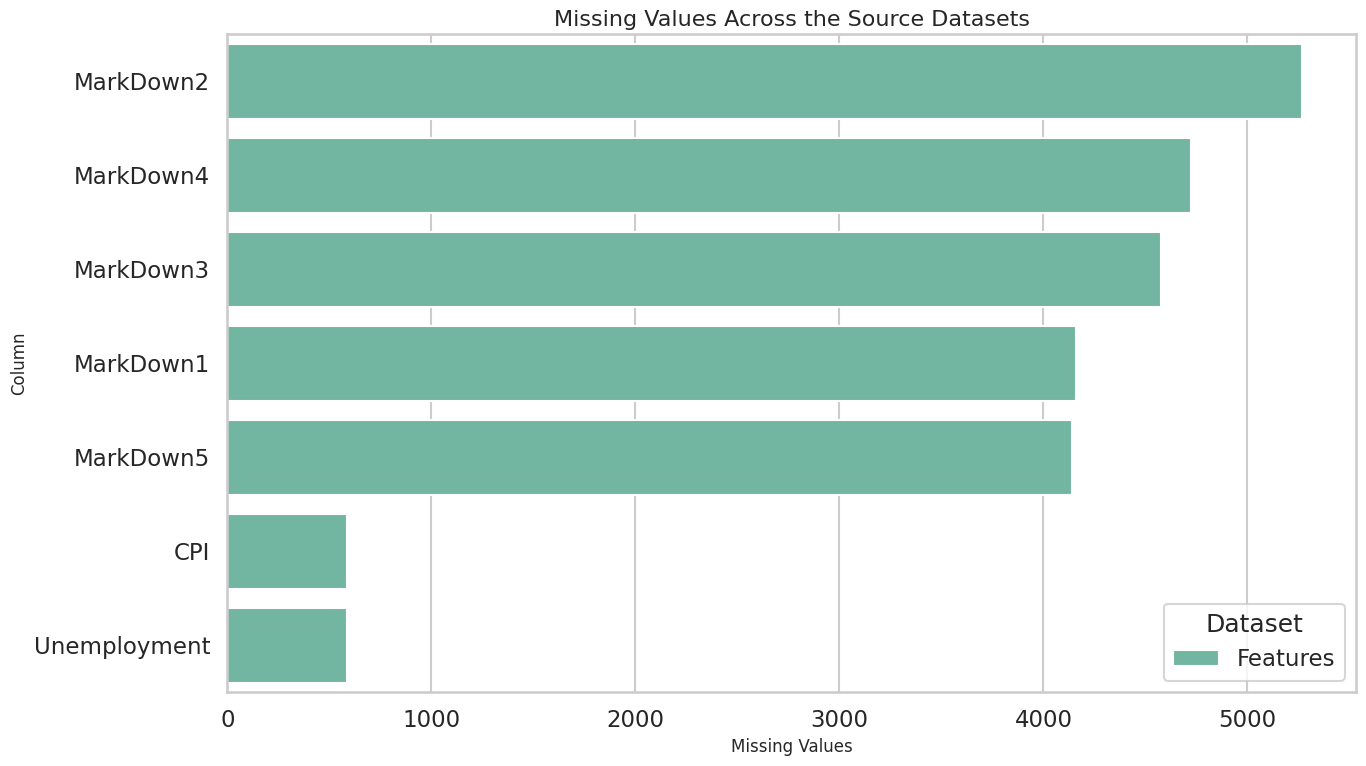

In [9]:
# Code Cell 08: Visualize the missing-value counts so concentration points stand out quickly.

# Only columns with missing values are kept for plotting.
missing_plot_df = missing_summary_df.loc[missing_summary_df["Missing_Values"] > 0].copy()
plt.figure(figsize=(14, 8))  # A taller figure is used because several markdown columns appear in the features table.

# A horizontal bar chart makes it easy to compare missing counts by column and dataset.
sns.barplot(data=missing_plot_df, x="Missing_Values", y="Column", hue="Dataset", palette="Set2")
plt.title("Missing Values Across the Source Datasets")  # A direct title clarifies the purpose of the plot.
plt.xlabel("Missing Values")  # The x-axis shows the number of missing records.
plt.ylabel("Column")  # The y-axis lists the affected columns.
plt.tight_layout()  # The layout is tightened so labels do not overlap.
plt.show()  # The missing-value chart is rendered in the notebook.
plt.close("all")  # Figures are closed after rendering to keep the notebook execution stable.


### 🤔 What did you know about your dataset?


📌 **Data understanding summary**

At this stage, the dataset has a clear business structure. The sales table captures weekly department-level performance, the features table captures the outside conditions and promotional activity around each store-week, and the stores table explains the physical store profile.

The key learning is that this is not a simple sales table. It is a retail planning dataset. Sales can be compared by store, department, time, holiday status, promotion intensity, and economic conditions. This makes it suitable for several connected tasks: sales trend analysis, anomaly detection, store segmentation, proxy department association rules, and demand forecasting.

The main data risk is not duplication. The main risk is how missing markdowns and a small number of missing economic values are handled. If markdowns are misunderstood, promotions may look weaker or stronger than they really are. If time fields are not prepared correctly, forecasting can become unreliable.


## 🧠 ***2. Understanding Your Variables***


In [10]:
# Code Cell 09: Check columns present in each dataset.

# Compare column names across all three source tables.
columns_summary_df = pd.DataFrame(
    {
        'Sales Columns': pd.Series(sales_df.columns),
        'Features Columns': pd.Series(features_df.columns),
        'Stores Columns': pd.Series(stores_df.columns),
    }
)

# Display column list.
display(columns_summary_df)


,Sales Columns,Features Columns,Stores Columns
0,Store,Store,Store
1,Dept,Date,Type
2,Date,Temperature,Size
3,Weekly_Sales,Fuel_Price,NaN
4,IsHoliday,MarkDown1,NaN
5,NaN,MarkDown2,NaN
6,NaN,MarkDown3,NaN
7,NaN,MarkDown4,NaN
8,NaN,MarkDown5,NaN
9,NaN,CPI,NaN


In [11]:
# Code Cell 10: Describe the numeric variables in each source dataset.
display(Markdown("#### Sales Dataset Numeric Summary"))  # A heading keeps the three summary tables visually separate.
display(sales_df.describe(include=[np.number]).T)  # The sales numeric summary helps review scale and dispersion.
display(Markdown("#### Features Dataset Numeric Summary"))  # A heading introduces the feature summary.

# The feature numeric summary highlights markdown and economic ranges.
display(features_df.describe(include=[np.number]).T)
display(Markdown("#### Stores Dataset Numeric Summary"))  # A heading introduces the store summary.

# The store numeric summary shows store identifiers and size distribution.
display(stores_df.describe(include=[np.number]).T)


#### Sales Dataset Numeric Summary

,count,mean,std,min,25%,50%,75%,max
Store,"421,570.00",22.20,12.79,1.00,11.00,22.00,33.00,45.00
Dept,"421,570.00",44.26,30.49,1.00,18.00,37.00,74.00,99.00
Weekly_Sales,"421,570.00","15,981.26","22,711.18","-4,988.94","2,079.65","7,612.03","20,205.85","693,099.36"


#### Features Dataset Numeric Summary

,count,mean,std,min,25%,50%,75%,max
Store,"8,190.00",23.00,12.99,1.00,12.00,23.00,34.00,45.00
Temperature,"8,190.00",59.36,18.68,-7.29,45.90,60.71,73.88,101.95
Fuel_Price,"8,190.00",3.41,0.43,2.47,3.04,3.51,3.74,4.47
MarkDown1,"4,032.00","7,032.37","9,262.75","-2,781.45","1,577.53","4,743.58","8,923.31","103,184.98"
MarkDown2,"2,921.00","3,384.18","8,793.58",-265.76,68.88,364.57,"2,153.35","104,519.54"
MarkDown3,"3,613.00","1,760.10","11,276.46",-179.26,6.60,36.26,163.15,"149,483.31"
MarkDown4,"3,464.00","3,292.94","6,792.33",0.22,304.69,"1,176.42","3,310.01","67,474.85"
MarkDown5,"4,050.00","4,132.22","13,086.69",-185.17,"1,440.83","2,727.14","4,832.56","771,448.10"
CPI,"7,605.00",172.46,39.74,126.06,132.36,182.76,213.93,228.98
Unemployment,"7,605.00",7.83,1.88,3.68,6.63,7.81,8.57,14.31


#### Stores Dataset Numeric Summary

,count,mean,std,min,25%,50%,75%,max
Store,45.00,23.00,13.13,1.00,12.00,23.00,34.00,45.00
Size,45.00,"130,287.60","63,825.27","34,875.00","70,713.00","126,512.00","202,307.00","219,622.00"


### 📝 Variables Description


📚 **How the variables fit together**

The variables can be read as four business blocks:

- **Sales identity:** `Store`, `Dept`, and `Date` tell us where and when the sale happened.
- **Sales outcome:** `Weekly_Sales` tells us the value generated by that store-department-week.
- **Store profile:** `Type` and `Size` describe the kind of store. These help explain why some stores naturally sell more than others.
- **Business conditions:** `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, `IsHoliday`, and markdown fields describe the weekly environment around sales.

📌 **Business meaning**

These variables are useful because they combine demand, store characteristics, promotion activity, and external conditions. That combination is exactly what a retail planning team needs for segmentation and forecasting.


### 🔢 Check Unique Values for each variable


In [12]:
# Code Cell 11: Check the number of unique values for each column in the source datasets.

# Sales uniqueness counts are summarized into a table.
sales_unique_df = sales_df.nunique(dropna=False).reset_index(name="Unique_Values").rename(columns={"index": "Column"})
sales_unique_df["Dataset"] = "Sales"  # The source dataset is added for clear identification.

# Feature uniqueness counts are summarized in the same format.
features_unique_df = features_df.nunique(dropna=False).reset_index(name="Unique_Values").rename(columns={"index": "Column"})
features_unique_df["Dataset"] = "Features"  # The source dataset label is attached.

# Store uniqueness counts are summarized in the same format.
stores_unique_df = stores_df.nunique(dropna=False).reset_index(name="Unique_Values").rename(columns={"index": "Column"})
stores_unique_df["Dataset"] = "Stores"  # The source dataset label is attached.

# The three uniqueness tables are stacked together.
unique_summary_df = pd.concat([sales_unique_df, features_unique_df, stores_unique_df], ignore_index=True)
display(unique_summary_df)


,Column,Unique_Values,Dataset
0,Store,45,Sales
1,Dept,81,Sales
2,Date,143,Sales
3,Weekly_Sales,359464,Sales
4,IsHoliday,2,Sales
5,Store,45,Features
6,Date,182,Features
7,Temperature,4178,Features
8,Fuel_Price,1011,Features
9,MarkDown1,4024,Features


## 🛠️ ***3. Data Wrangling***


### 💻 Data Wrangling Code


In [13]:
# Code Cell 12: Merge the datasets, clean the main fields, and build analysis-ready weekly and store-level tables.

# Project folders used later while saving outputs.
PROJECT_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/# specialization projects/3rd project Integrated Retail Analytics for Store Optimization')
DATA_DIR = PROJECT_ROOT / 'dateset'
OUTPUT_DIR = PROJECT_ROOT / 'colab_outputs'
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Convert date columns before merging and time-based analysis.
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d/%m/%Y')
features_df['Date'] = pd.to_datetime(features_df['Date'], format='%d/%m/%Y')

# Convert holiday flags into clean boolean values.
sales_df['IsHoliday'] = sales_df['IsHoliday'].astype(bool)
features_df['IsHoliday'] = features_df['IsHoliday'].astype(bool)

# Sort records so later time-based logic stays stable.
sales_df = sales_df.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
features_df = features_df.sort_values(['Store', 'Date']).reset_index(drop=True)
stores_df = stores_df.sort_values(['Store']).reset_index(drop=True)

# Markdown columns are grouped because they are handled together in cleaning and feature creation.
markdown_columns = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
]

# Economic context columns are grouped so missing values can be filled consistently by store.
economic_columns = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
]

# Sales records are joined with weekly feature data using store and date as common keys.
merged_df = sales_df.merge(
    features_df,
    on=["Store", "Date"],
    how="left",
    suffixes=("_sales", "_feature"),
)

# Store attributes are added after the sales-feature merge.
merged_df = merged_df.merge(stores_df, on="Store", how="left")

# Holiday flags from both tables are combined into one final holiday column.
merged_df["IsHoliday"] = (
    merged_df["IsHoliday_sales"].fillna(False)
    | merged_df["IsHoliday_feature"].fillna(False)
)

# Temporary holiday columns are removed after the final flag is created.
merged_df = merged_df.drop(columns=["IsHoliday_sales", "IsHoliday_feature"])
merged_df[markdown_columns] = merged_df[markdown_columns].fillna(0.0)

# Economic values are filled within each store to avoid mixing store-level patterns.
for column_name in economic_columns:
    merged_df[column_name] = merged_df.groupby("Store")[column_name].transform(
        lambda series: series.ffill().bfill()
    )

# Negative sales are capped at zero because final sales should not go below zero.
merged_df["Weekly_Sales_Clean"] = merged_df["Weekly_Sales"].clip(lower=0.0)
merged_df["Year"] = merged_df["Date"].dt.year
merged_df["Month"] = merged_df["Date"].dt.month
merged_df["Quarter"] = merged_df["Date"].dt.quarter
merged_df["WeekOfYear"] = merged_df["Date"].dt.isocalendar().week.astype(int)
merged_df["Holiday_Week"] = merged_df["IsHoliday"].astype(int)
merged_df["Total_MarkDown"] = merged_df[markdown_columns].sum(axis=1)

merged_df = merged_df.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

# Weekly totals are created for the forecasting part of the project.
weekly_df = merged_df.groupby("Date", as_index=False).agg(
    Weekly_Sales=("Weekly_Sales_Clean", "sum"),
    Holiday_Week=("Holiday_Week", "max"),
    Mean_Temperature=("Temperature", "mean"),
    Mean_Fuel_Price=("Fuel_Price", "mean"),
    Mean_CPI=("CPI", "mean"),
    Mean_Unemployment=("Unemployment", "mean"),
    Mean_Total_MarkDown=("Total_MarkDown", "mean"),
    Store_Count=("Store", "nunique"),
    Department_Count=("Dept", "nunique"),
)

weekly_df["Year"] = weekly_df["Date"].dt.year
weekly_df["Month"] = weekly_df["Date"].dt.month
weekly_df["Quarter"] = weekly_df["Date"].dt.quarter
weekly_df["WeekOfYear"] = weekly_df["Date"].dt.isocalendar().week.astype(int)
weekly_df["Time_Index"] = np.arange(len(weekly_df))

# Holiday sales averages are calculated separately for later store profiling.
holiday_store_sales_df = (
    merged_df.loc[merged_df["Holiday_Week"] == 1]
    .groupby("Store", as_index=False)["Weekly_Sales_Clean"]
    .mean()
    .rename(columns={"Weekly_Sales_Clean": "Holiday_Sales_Mean"})
)

# Store-level profiles summarize behavior across the full available history.
store_profiles = merged_df.groupby(["Store", "Type", "Size"], as_index=False).agg(
    Mean_Weekly_Sales=("Weekly_Sales_Clean", "mean"),
    Median_Weekly_Sales=("Weekly_Sales_Clean", "median"),
    Sales_Volatility=("Weekly_Sales_Clean", "std"),
    Markdown_Intensity=("Total_MarkDown", "mean"),
    Mean_Temperature=("Temperature", "mean"),
    Mean_Fuel_Price=("Fuel_Price", "mean"),
    Mean_CPI=("CPI", "mean"),
    Mean_Unemployment=("Unemployment", "mean"),
    Department_Count=("Dept", "nunique"),
)

store_profiles = store_profiles.merge(
    holiday_store_sales_df,
    on="Store",
    how="left",
)

store_profiles["Holiday_Sales_Mean"] = store_profiles["Holiday_Sales_Mean"].fillna(
    store_profiles["Mean_Weekly_Sales"]
)
store_profiles["Sales_Volatility"] = store_profiles["Sales_Volatility"].fillna(0.0)

# A short summary confirms the prepared tables before moving forward.
wrangling_summary_df = pd.DataFrame(
    {
        "Prepared Table": [
            "Merged Detail Table",
            "Weekly Forecast Table",
            "Store Profile Table",
        ],
        "Rows": [
            merged_df.shape[0],
            weekly_df.shape[0],
            store_profiles.shape[0],
        ],
        "Columns": [
            merged_df.shape[1],
            weekly_df.shape[1],
            store_profiles.shape[1],
        ],
    }
)

display(wrangling_summary_df)
display(weekly_df.head())
display(store_profiles.head())


,Prepared Table,Rows,Columns
0,Merged Detail Table,421570,23
1,Weekly Forecast Table,143,15
2,Store Profile Table,45,13


,Date,Weekly_Sales,Holiday_Week,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Mean_Total_MarkDown,Store_Count,Department_Count,Year,Month,Quarter,WeekOfYear,Time_Index
0,2010-02-05,"49,750,875.98",0,33.28,2.72,167.40,8.58,0.00,45,78,2010,2,1,5,0
1,2010-02-12,"48,336,800.10",1,33.36,2.70,167.38,8.57,0.00,45,79,2010,2,1,6,1
2,2010-02-19,"48,277,902.33",0,37.04,2.67,167.34,8.58,0.00,45,79,2010,2,1,7,2
3,2010-02-26,"43,970,440.65",0,38.63,2.69,167.69,8.56,0.00,45,78,2010,2,1,8,3
4,2010-03-05,"46,872,715.16",0,42.37,2.73,167.73,8.57,0.00,45,79,2010,3,1,9,4


,Store,Type,Size,Mean_Weekly_Sales,Median_Weekly_Sales,Sales_Volatility,Markdown_Intensity,Mean_Temperature,Mean_Fuel_Price,Mean_CPI,Mean_Unemployment,Department_Count,Holiday_Sales_Mean
0,1,A,151315,"21,710.93","10,289.38","27,748.64","7,331.80",68.22,3.22,216.00,7.61,77,"23,039.39"
1,2,A,202307,"26,898.53","14,333.53","33,077.23","10,039.57",68.11,3.22,215.65,7.62,78,"28,799.05"
2,3,B,37392,"6,373.17","2,804.82","14,250.97","2,460.90",71.30,3.22,219.40,7.18,72,"6,916.45"
3,4,A,205863,"29,161.34","15,116.81","34,583.57","9,698.51",62.18,3.22,128.68,5.97,78,"30,854.23"
4,5,B,34875,"5,053.46","2,582.66","8,068.19","2,924.78",69.20,3.22,216.58,6.30,72,"5,617.26"


### 💡 What manipulations have you done and insights found?
